In [1]:
import tensorflow as tf

In [49]:
import os
import numpy as np
from pandas import read_csv
from numpy import dstack
def get_values_around_max(series):
    """
    Returns the 20 values before and after the maximum value in the given Pandas Series.
    If there are not 20 values before or after the maximum, it will return None.
    """
    max_value = series.max()
    max_index = series.idxmax()

    start = max_index - 20
    end = max_index + 21

    if start < 0 or end > len(series):
        return None

    return series.iloc[start:end]
# load a single file as a numpy array
def load_file(filepath):
  fall = read_csv(filepath, header=0)
  t=np.sqrt(fall['accel_x_list']**2+fall['accel_y_list']**2+fall['accel_z_list']**2)
  return get_values_around_max(t)

# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
  loaded = []
  for name in filenames:
    data = load_file(prefix + name)
    if data is None:
       print(name)
    else:
      loaded.append(data.tolist())
      #loaded = dstack(loaded)
  # stack group so that features are the 3rd dimension
  #loaded = dstack(loaded)
  return loaded

def get_files_in_dir(directory, file_pattern='accel.csv'):
    """
    Returns a list of all files in the given directory that match the file_pattern.
    """
    file_list = []
    print(directory)
    for filename in os.listdir(directory):
        if filename.endswith(file_pattern):
            file_list.append(os.path.join(directory, filename))
    return file_list

# load a dataset group, such as train or test
def load_dataset_group(group, prefix='C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/'):
#def load_dataset_group(group, prefix='/Users/song/Downloads/WEDA-FALL/dataset/10Hz/'):  
  filepath = prefix + group + '/'
  # load all 9 files as a single array
  filenames = get_files_in_dir(filepath, file_pattern='accel.csv')

  # load input data
  X = load_group(filenames)
  # load class output
  #y = load_file(prefix + group + '/y_'+group+'.txt')
  return X
trainX = load_dataset_group('F01')
#trainX = trainX.append(load_dataset_group('F02'))
trainX = np.concatenate((trainX, load_dataset_group('F02')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('F03')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('F04')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('F05')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('F06')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('F07')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('F08')), axis=0)
trainY = np.ones((len(trainX),1)) 
lenofone= len(trainX)
print("fall:"+str(lenofone))
trainX = np.concatenate((trainX, load_dataset_group('D01')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('D02')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('D03')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('D04')), axis=0)
#trainX = np.concatenate((trainX, load_dataset_group('D05')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('D06')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('D07')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('D08')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('D09')), axis=0)
#trainX = np.concatenate((trainX, load_dataset_group('D10')), axis=0)
trainX = np.concatenate((trainX, load_dataset_group('D11')), axis=0)
trainY = np.concatenate((trainY, np.zeros((len(trainX)-lenofone, 1))), axis=0)
print(len(trainX))

C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F01/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F02/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F03/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F04/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/U08_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/U11_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F06/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F06/U05_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F07/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F07/U08_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U06_R01_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U14_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U14_R04_accel.csv
fall:343
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D01/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D01/U02_R0

In [33]:
print(lenofone)

374


In [55]:
trainY[715]

array([0.])

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(trainX, trainY, test_size=0.2, random_state=42)

In [51]:
X_train.shape,X_test.shape

((572, 41), (144, 41))

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
# Define the 1D CNN model
model = Sequential()
model.add(Conv1D(32, 3, activation='relu', input_shape=(41, 1)))
model.add(MaxPooling1D(2))
model.add(Conv1D(64, 3, activation='relu'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train.reshape(-1, 41, 1), y_train, epochs=10, batch_size=32, validation_data=(X_test.reshape(-1, 41, 1), y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test.reshape(-1, 41, 1), y_test)
print(f'Test loss: {loss:.4f}, Test accuracy: {accuracy:.4f}')

Epoch 1/10


C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6640 - loss: 0.6385 - val_accuracy: 0.8750 - val_loss: 0.3110
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8608 - loss: 0.3043 - val_accuracy: 0.8819 - val_loss: 0.3017
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8707 - loss: 0.3139 - val_accuracy: 0.8819 - val_loss: 0.3059
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8768 - loss: 0.2638 - val_accuracy: 0.8889 - val_loss: 0.2952
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8906 - loss: 0.2456 - val_accuracy: 0.8819 - val_loss: 0.2826
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8891 - loss: 0.2458 - val_accuracy: 0.8819 - val_loss: 0.2873
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9089 - loss: 0.2315 - val_accuracy: 0.8889 - val_loss: 0.2776
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8965 - loss: 0.2287 - val_accuracy: 0.8750 - val_loss: 0.2720
Ep

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
# fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy):
	verbose, epochs, batch_size = 0, 10, 32
	model = Sequential()
	model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(41,1)))
	model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
	model.add(Dropout(0.5))
	model.add(MaxPooling1D(pool_size=2))
	model.add(Flatten())
	model.add(Dense(100, activation='relu'))
	model.add(Dense(1, activation='sigmoid'))
	model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
	# fit network
	model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose)
	# evaluate model
	_, accuracy = model.evaluate(testX, testy, batch_size=batch_size, verbose=0)
	return accuracy

In [ ]:
from sklearn.preprocessing import StandardScaler

# Assuming 'X' is your input data with shape (100, 50)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [64]:
from numpy import mean,std
# summarize scores
def summarize_results(scores):
    print(scores)
    m, s = mean(scores), std(scores)
    print('Accuracy: %.3f%% (+/-%.3f)' % (m, s))
 
# run an experiment
def run_experiment(repeats=10):
    # load data
    # repeat experiment
    scores = list()
    for r in range(repeats):
        score = evaluate_model(X_train, y_train, X_test,  y_test)
        score = score * 100.0
        print('>#%d: %.3f' % (r+1, score))
        scores.append(score)
 # summarize results
    summarize_results(scores)
 
# run the experiment
run_experiment()

>#1: 93.056
>#2: 93.056
>#3: 93.750
>#4: 92.361
>#5: 93.750
>#6: 93.750
>#7: 94.444
>#8: 93.750
>#9: 92.361
>#10: 95.139
[93.05555820465088, 93.05555820465088, 93.75, 92.36111044883728, 93.75, 93.75, 94.44444179534912, 93.75, 92.36111044883728, 95.13888955116272]
Accuracy: 93.542% (+/-0.825)


In [60]:
from keras.utils import to_categorical
from matplotlib import pyplot
# plot a histogram of each variable in the dataset
def plot_variable_distributions(trainX):
    longX=trainX
    # flatten windows
    pyplot.figure()
    xaxis = None
    for i in range(longX.shape[1]):
        ax = pyplot.subplot(longX.shape[1], 1, i+1, sharex=xaxis)
        ax.set_xlim(-1, 1)
        if i == 0:
            xaxis = ax
        pyplot.hist(longX[:, i], bins=100)
        pyplot.show()

C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F01/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F02/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F03/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F04/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/U08_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/U11_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F06/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F06/U05_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F07/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F07/U08_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U06_R01_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U14_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U14_R04_accel.csv
fall:343
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D01/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D01/U02_R0

C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>p=False #1: 90.972
>p=False #2: 88.194
>p=False #3: 90.278
>p=False #4: 84.722
>p=False #5: 90.278
>p=False #6: 88.889
>p=False #7: 86.806
>p=False #8: 88.194
>p=False #9: 87.500
>p=False #10: 88.194


C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>p=True #1: 93.750


...

C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>p=True #9: 94.444


C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>p=True #10: 92.361
[[90.97222089767456, 88.19444179534912, 90.27777910232544, 84.72222089767456, 90.27777910232544, 88.88888955116272, 86.80555820465088, 88.19444179534912, 87.5, 88.19444179534912], [93.75, 94.44444179534912, 93.75, 93.05555820465088, 93.75, 93.75, 93.75, 92.36111044883728, 94.44444179534912, 92.36111044883728]] [False, True]
Param=False: 88.403% (+/-1.758)
Param=True: 93.542% (+/-0.698)


C:\Users\ssli\AppData\Local\Temp\ipykernel_13196\3388509388.py:138: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(scores, labels=params)


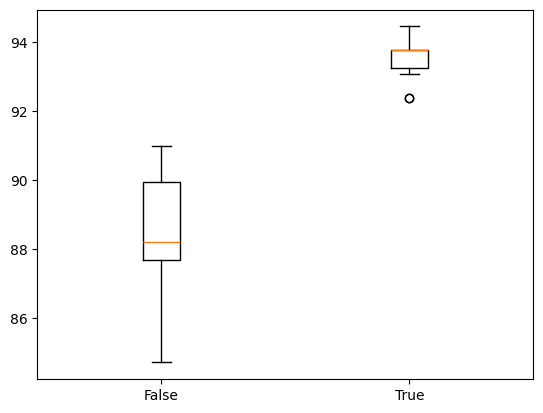

In [6]:
# cnn model with standardization
from numpy import mean
from numpy import std
from numpy import dstack
from pandas import read_csv
from matplotlib import pyplot
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import os
import numpy as np
from sklearn.model_selection import train_test_split

def get_values_around_max(series):
    """
    Returns the 20 values before and after the maximum value in the given Pandas Series.
    If there are not 20 values before or after the maximum, it will return None.
    """
    max_value = series.max()
    max_index = series.idxmax()

    start = max_index - 20
    end = max_index + 21

    if start < 0 or end > len(series):
        return None

    return series.iloc[start:end]
# load a single file as a numpy array
def load_file(filepath):
  fall = read_csv(filepath, header=0)
  t=np.sqrt(fall['accel_x_list']**2+fall['accel_y_list']**2+fall['accel_z_list']**2)
  return get_values_around_max(t)

# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
  loaded = []
  for name in filenames:
    data = load_file(prefix + name)
    if data is None:
       print(name)
    else:
      loaded.append(data.tolist())
      #loaded = dstack(loaded)
  # stack group so that features are the 3rd dimension
  #loaded = dstack(loaded)
  return loaded

def get_files_in_dir(directory, file_pattern='accel.csv'):
    """
    Returns a list of all files in the given directory that match the file_pattern.
    """
    file_list = []
    print(directory)
    for filename in os.listdir(directory):
        if filename.endswith(file_pattern):
            file_list.append(os.path.join(directory, filename))
    return file_list

# load a dataset group, such as train or test
def load_dataset_group(group, prefix='C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/'):
#def load_dataset_group(group, prefix='/Users/song/Downloads/WEDA-FALL/dataset/10Hz/'):  
  filepath = prefix + group + '/'
  # load all 9 files as a single array
  filenames = get_files_in_dir(filepath, file_pattern='accel.csv')

  # load input data
  X = load_group(filenames)
  # load class output
  #y = load_file(prefix + group + '/y_'+group+'.txt')
  return X

def prepare_data():
	trainX = load_dataset_group('F01')
	#trainX = trainX.append(load_dataset_group('F02'))
	trainX = np.concatenate((trainX, load_dataset_group('F02')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('F03')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('F04')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('F05')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('F06')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('F07')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('F08')), axis=0)
	trainY = np.ones((len(trainX),1)) 
	lenofone= len(trainX)
	print("fall:"+str(lenofone))
	trainX = np.concatenate((trainX, load_dataset_group('D01')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('D02')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('D03')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('D04')), axis=0)
	#trainX = np.concatenate((trainX, load_dataset_group('D05')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('D06')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('D07')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('D08')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('D09')), axis=0)
	#trainX = np.concatenate((trainX, load_dataset_group('D10')), axis=0)
	trainX = np.concatenate((trainX, load_dataset_group('D11')), axis=0)
	trainY = np.concatenate((trainY, np.zeros((len(trainX)-lenofone, 1))), axis=0)
	print(len(trainX))
	X_train, X_test, y_train, y_test = train_test_split(trainX, trainY, test_size=0.2, random_state=42)
	return X_train, y_train, X_test, y_test

# standardize data
def scale_data(X_train, X_test, standardize):
	if standardize:
		scaler = StandardScaler()
		X_train = scaler.fit_transform(X_train)
		X_test = scaler.fit_transform(X_test)
	return X_train, X_test

# fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy, param):
	verbose, epochs, batch_size = 0, 10, 32
	# scale data
	trainX, testX = scale_data(trainX, testX, param)
	model = Sequential()
	model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(41,1)))
	model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
	model.add(Dropout(0.5))
	model.add(MaxPooling1D(pool_size=2))
	model.add(Flatten())
	model.add(Dense(100, activation='relu'))
	model.add(Dense(1, activation='sigmoid'))
	model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
	# fit network
	model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose)
	# evaluate model
	_, accuracy = model.evaluate(testX, testy, batch_size=batch_size, verbose=0)
	return accuracy

# summarize scores
def summarize_results(scores, params):
	print(scores, params)
	# summarize mean and standard deviation
	for i in range(len(scores)):
		m, s = mean(scores[i]), std(scores[i])
		print('Param=%s: %.3f%% (+/-%.3f)' % (params[i], m, s))
	# boxplot of scores
	pyplot.boxplot(scores, labels=params)
	pyplot.savefig('exp_cnn_standardize.png')

# run an experiment
def run_experiment(params, repeats=10):
	# load data
	trainX, trainy, testX, testy = prepare_data()
	# test each parameter
	all_scores = list()
	for p in params:
		# repeat experiment
		scores = list()
		for r in range(repeats):
			score = evaluate_model(trainX, trainy, testX, testy, p)
			score = score * 100.0
			print('>p=%s #%d: %.3f' % (p, r+1, score))
			scores.append(score)
		all_scores.append(scores)
	# summarize results
	summarize_results(all_scores, params)

# run the experiment
n_params = [False, True]
run_experiment(n_params)

this is for test filters

C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F01/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F02/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F03/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F04/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/U08_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/U11_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F06/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F06/U05_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F07/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F07/U08_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U06_R01_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U14_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U14_R04_accel.csv
fall:343
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D01/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D01/U02_R0

C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>p=8 #1: 91.667


C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>p=8 #2: 88.194


...

C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>p=256 #9: 91.667


C:\Users\ssli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>p=256 #10: 93.056
[[91.66666865348816, 88.19444179534912, 88.19444179534912, 90.27777910232544, 87.5, 88.19444179534912, 90.97222089767456, 88.88888955116272, 88.19444179534912, 88.19444179534912], [91.66666865348816, 93.75, 91.66666865348816, 90.97222089767456, 91.66666865348816, 90.27777910232544, 90.97222089767456, 94.44444179534912, 90.27777910232544, 90.97222089767456], [91.66666865348816, 93.75, 93.05555820465088, 93.05555820465088, 91.66666865348816, 92.36111044883728, 93.75, 92.36111044883728, 92.36111044883728, 92.36111044883728], [93.75, 93.75, 91.66666865348816, 93.75, 92.36111044883728, 95.13888955116272, 93.05555820465088, 94.44444179534912, 93.75, 94.44444179534912], [93.05555820465088, 93.75, 93.75, 92.36111044883728, 90.97222089767456, 93.75, 94.44444179534912, 91.66666865348816, 93.05555820465088, 92.36111044883728], [90.97222089767456, 92.36111044883728, 92.36111044883728, 93.75, 93.05555820465088, 94.44444179534912, 95.13888955116272, 92.36111044883728, 91.666668653

C:\Users\ssli\AppData\Local\Temp\ipykernel_13196\1851106695.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(scores, labels=params)


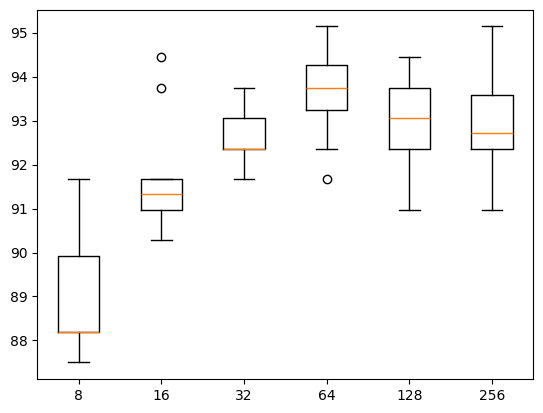

In [7]:
# fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy, n_filters):
	verbose, epochs, batch_size = 0, 10, 32
	trainX, testX = scale_data(trainX, testX, True)
	model = Sequential()
	model.add(Conv1D(filters=n_filters, kernel_size=3, activation='relu', input_shape=(41,1)))
	model.add(Conv1D(filters=n_filters, kernel_size=3, activation='relu'))
	model.add(Dropout(0.5))
	model.add(MaxPooling1D(pool_size=2))
	model.add(Flatten())
	model.add(Dense(100, activation='relu'))
	model.add(Dense(1, activation='sigmoid'))
	model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
	# fit network
	model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose)
	# evaluate model
	_, accuracy = model.evaluate(testX, testy, batch_size=batch_size, verbose=0)
	return accuracy

# summarize scores
def summarize_results(scores, params):
	print(scores, params)
	# summarize mean and standard deviation
	for i in range(len(scores)):
		m, s = mean(scores[i]), std(scores[i])
		print('Param=%d: %.3f%% (+/-%.3f)' % (params[i], m, s))
	# boxplot of scores
	pyplot.boxplot(scores, labels=params)
	pyplot.savefig('exp_cnn_filters.png')

# run an experiment
def run_experiment(params, repeats=10):
	# load data
	trainX, trainy, testX, testy = prepare_data()
	# test each parameter
	all_scores = list()
	for p in params:
		# repeat experiment
		scores = list()
		for r in range(repeats):
			score = evaluate_model(trainX, trainy, testX, testy, p)
			score = score * 100.0
			print('>p=%d #%d: %.3f' % (p, r+1, score))
			scores.append(score)
		all_scores.append(scores)
	# summarize results
	summarize_results(all_scores, params)

# run the experiment
n_params = [8, 16, 32, 64, 128, 256]
run_experiment(n_params)

this is for testing n_kernel

C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F01/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F02/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F03/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F04/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/U08_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F05/U11_R02_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F06/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F06/U05_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F07/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F07/U08_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U06_R01_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U14_R03_accel.csv
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/F08/U14_R04_accel.csv
fall:343
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D01/
C:/Users/ssli/Downloads/WEDAFALL/dataset/10Hz/D01/U02_R0

C:\Users\ssli\AppData\Local\Temp\ipykernel_13196\956265187.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(scores, labels=params)


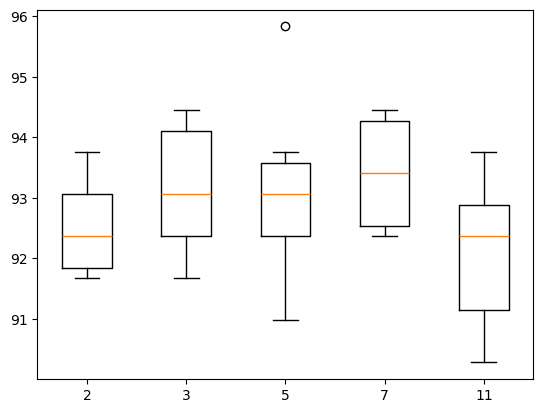

In [11]:
from tensorflow.keras.layers import Input
# fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy, n_kernel):
	verbose, epochs, batch_size = 0, 15, 32
	trainX, testX = scale_data(trainX, testX, True)
	model = Sequential()
	model.add(Input(shape=(41,1)))
	model.add(Conv1D(filters=64, kernel_size=n_kernel, activation='relu'))
	model.add(Conv1D(filters=64, kernel_size=n_kernel, activation='relu'))
	model.add(Dropout(0.5))
	model.add(MaxPooling1D(pool_size=2))
	model.add(Flatten())
	model.add(Dense(100, activation='relu'))
	model.add(Dense(1, activation='sigmoid'))
	model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
	# fit network
	model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose)
	# evaluate model
	_, accuracy = model.evaluate(testX, testy, batch_size=batch_size, verbose=0)
	return accuracy

# summarize scores
def summarize_results(scores, params):
	print(scores, params)
	# summarize mean and standard deviation
	for i in range(len(scores)):
		m, s = mean(scores[i]), std(scores[i])
		print('Param=%d: %.3f%% (+/-%.3f)' % (params[i], m, s))
	# boxplot of scores
	pyplot.boxplot(scores, labels=params)
	pyplot.savefig('exp_cnn_kernel.png')

# run an experiment
def run_experiment(params, repeats=10):
	# load data
	trainX, trainy, testX, testy = prepare_data()
	# test each parameter
	all_scores = list()
	for p in params:
		# repeat experiment
		scores = list()
		for r in range(repeats):
			score = evaluate_model(trainX, trainy, testX, testy, p)
			score = score * 100.0
			print('>p=%d #%d: %.3f' % (p, r+1, score))
			scores.append(score)
		all_scores.append(scores)
	# summarize results
	summarize_results(all_scores, params)

# run the experiment
n_params = [2, 3, 5, 7, 11]
run_experiment(n_params)